In [1]:
import pandas as pd

data = pd.read_csv("yield_df.csv")

In [2]:
data.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [10]:
X = pd.get_dummies(data.drop('hg/ha_yield', axis=1))
y = data['hg/ha_yield']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

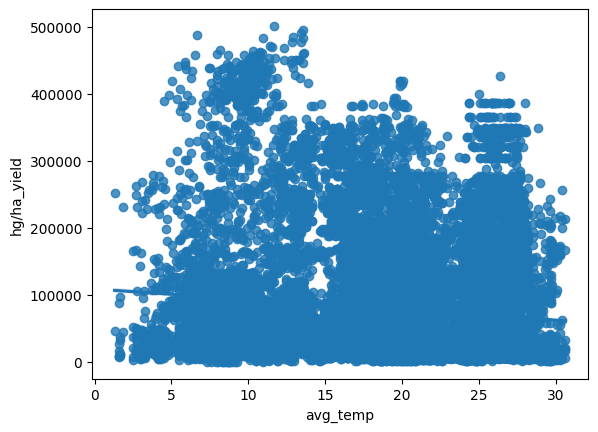

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    x=data['avg_temp'],
    y=data['hg/ha_yield']
)

plt.show()

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [15]:
lr = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor()

In [13]:
print(X_train.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [16]:
pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)
pred_rf = rf.predict(X_test)

In [17]:
from sklearn.metrics import r2_score

print("Linear Regression:", r2_score(y_test, pred_lr))
print("Decision Tree:", r2_score(y_test, pred_dt))
print("Random Forest:", r2_score(y_test, pred_rf))

Linear Regression: 0.7549001032684948
Decision Tree: 0.9799637813072409
Random Forest: 0.9888256919404637


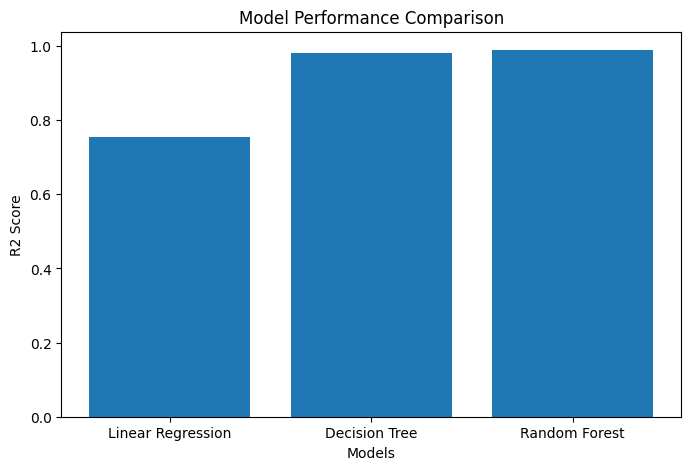

In [18]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Decision Tree', 'Random Forest']
scores = [0.7549, 0.9799, 0.9888]

plt.figure(figsize=(8,5))
plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Performance Comparison")

plt.show()

In [19]:
# Model Comparison Conclusion
# Three regression models were trained and evaluated using the R² score.
# Linear Regression achieved an R² score of 0.75, indicating moderate performance.
# Decision Tree performed significantly better with an R² score of 0.97.
# Random Forest achieved the highest R² score of 0.988, making it the best-performing model for this dataset.
# This suggests that the relationship between the features and crop yield is non-linear,
# which tree-based ensemble models like Random Forest can capture more effectively.
# Therefore, Random Forest is selected as the final model for crop yield prediction.